In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from finalpoints import *


In [2]:
import scipy
import numpy.fft
import scipy.fft

In [3]:
M = FinalPoints()

In [4]:
r_theta, chebyshev1, angles=  M.points(1, "c")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [5]:
xyz = M.pol2cart(r_theta, angles)

IndexError: list assignment index out of range

In [ ]:
chebyshev2, pointC, derC=  M.points(4, "c")
chebyshev3, pointC, derC =  M.points(5, "c")
chebyshev4, pointC, derC =  M.points(6, "c")

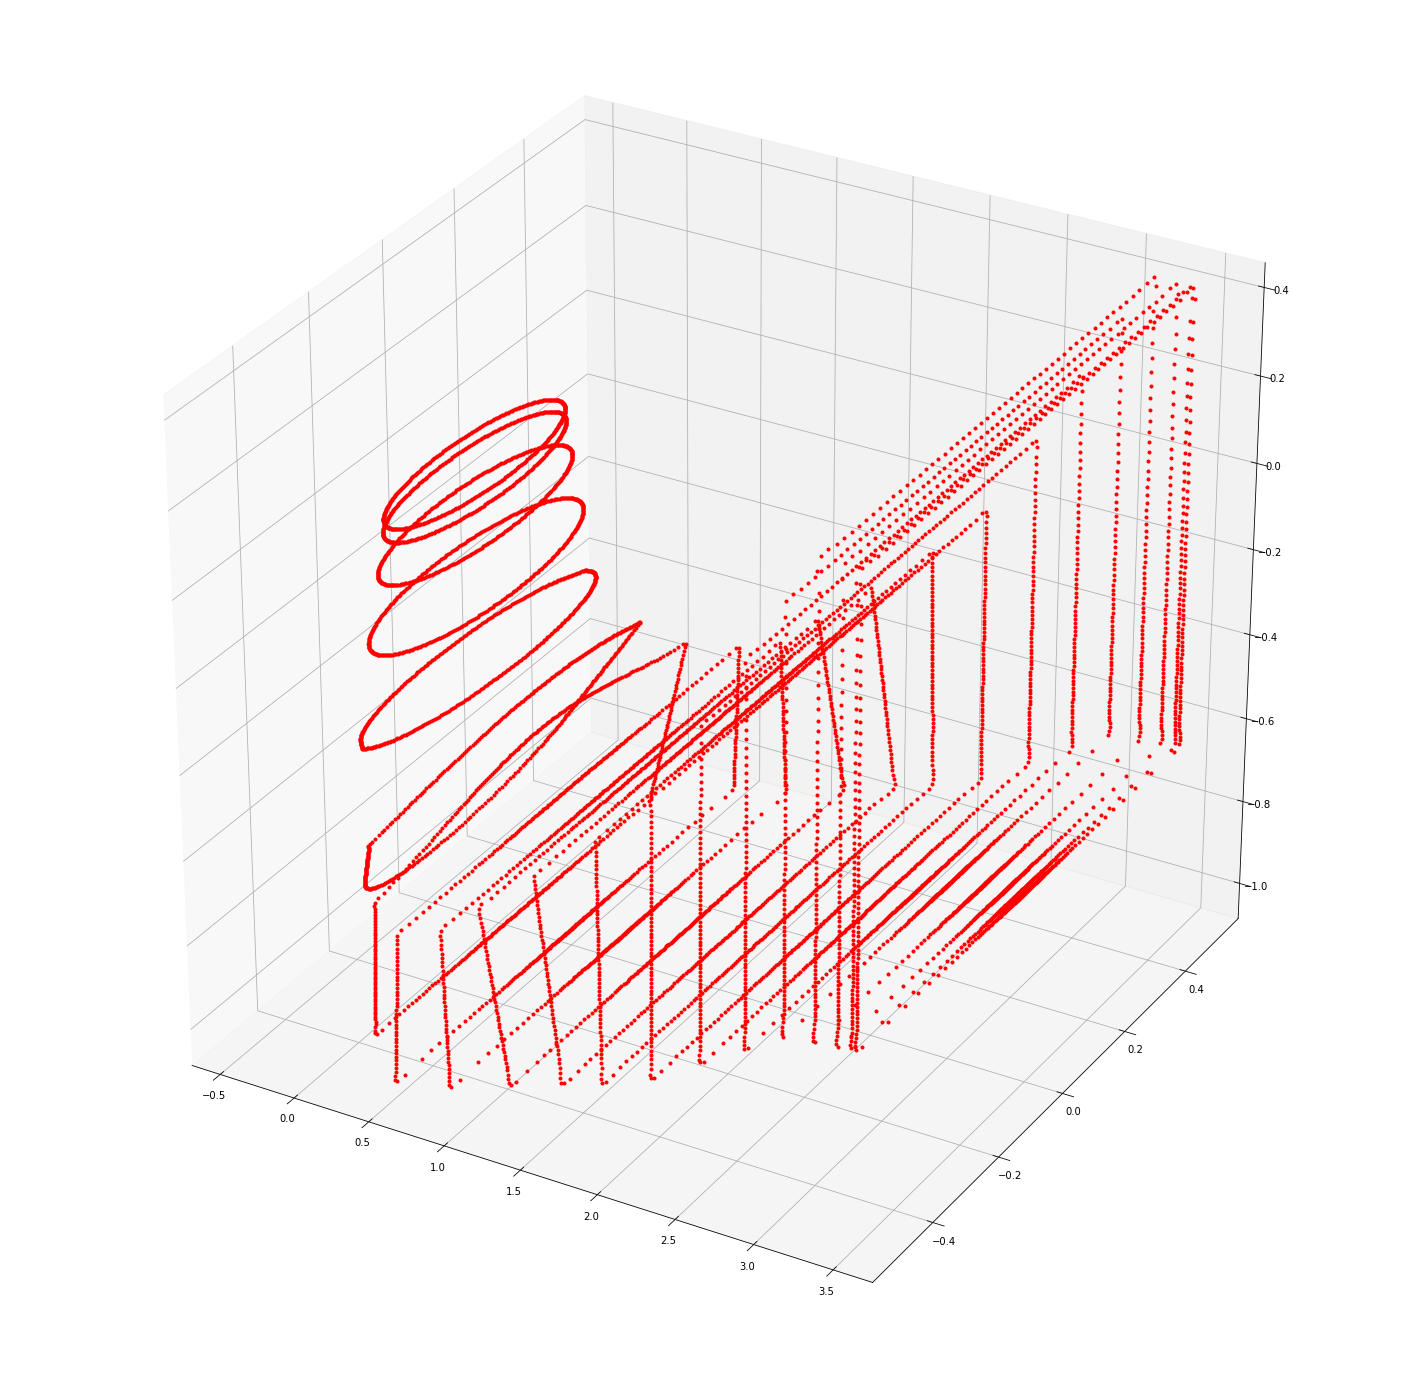

In [5]:
plt.figure(figsize=(25,25))
ax2 = plt.axes(projection='3d')
x = []
y = []
z = []
for k in range(20):
    x.extend([chebyshev1[k][i][0] for i in range(360)])
    y.extend([chebyshev1[k][i][1] for i in range(360)])
    z.extend([chebyshev1[k][i][2] for i in range(360)])
ax2.plot3D(x, y, z, "r.")
#baseline1equal = open('baseline1equal.txt', 'w')
#print(equal1, file = baseline1equal)

<Figure size 720x720 with 0 Axes>

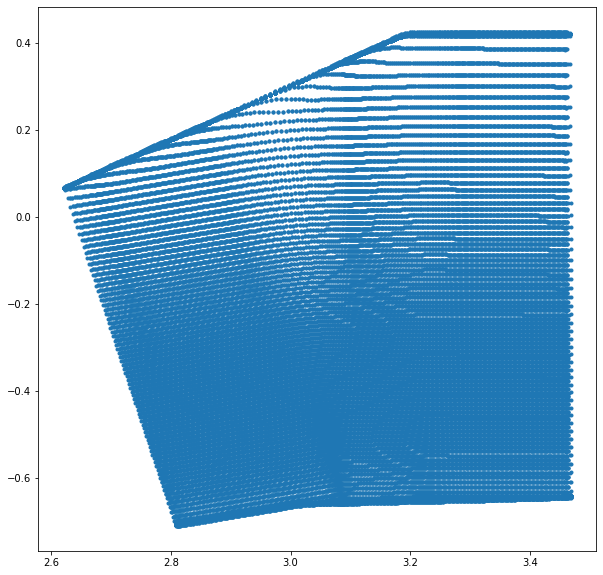

In [63]:

r = np.array([x, y, z])
rfft = np.fft.rfftn(r)
xr = np.fft.fft(x, n = 1000000, axis = 0)
yr = np.fft.fft(y, n = 1000000, axis = 0)
zr = np.fft.rfft(z, n = 1000000, axis = 0)


a = np.linspace(0,  len(r[0]), len(r[0]))
plt.figure(figsize=(10, 10))

for i in range(len(rfft[1])-1000,len(rfft[1]) ):
    rfft[0][i] = rfft[0][i]*np.exp(-i*i)
    rfft[1][i] = rfft[0][i]*np.exp(-i*i)
    rfft[2][i] = rfft[0][i]*np.exp(-i*i)

#plt.plot(a[:], r[0][:])
#plt.plot(a[5000:], r[1][5000:])
#plt.plot(a[5000:], r[2][5000:])
smooth = np.fft.irfftn(rfft)
plt.figure(figsize=(10, 10))
plt.plot(smooth[0][600000:], smooth[2][600000:], ".")

# figure out how the k values are sorted out
# start from 0, 1, 2, 3, 4 ... -4, -3, -2, -1
# real only gives you from 0, 1, 2, 3, ....., num
# if have 512 k values
#if |kx| > (2/3)(512) and |kx| > (2/3)(512)  and 
# do a(kx, jy, kz)*e^(-sqrt(kx^2 + ky^2+kz^2)

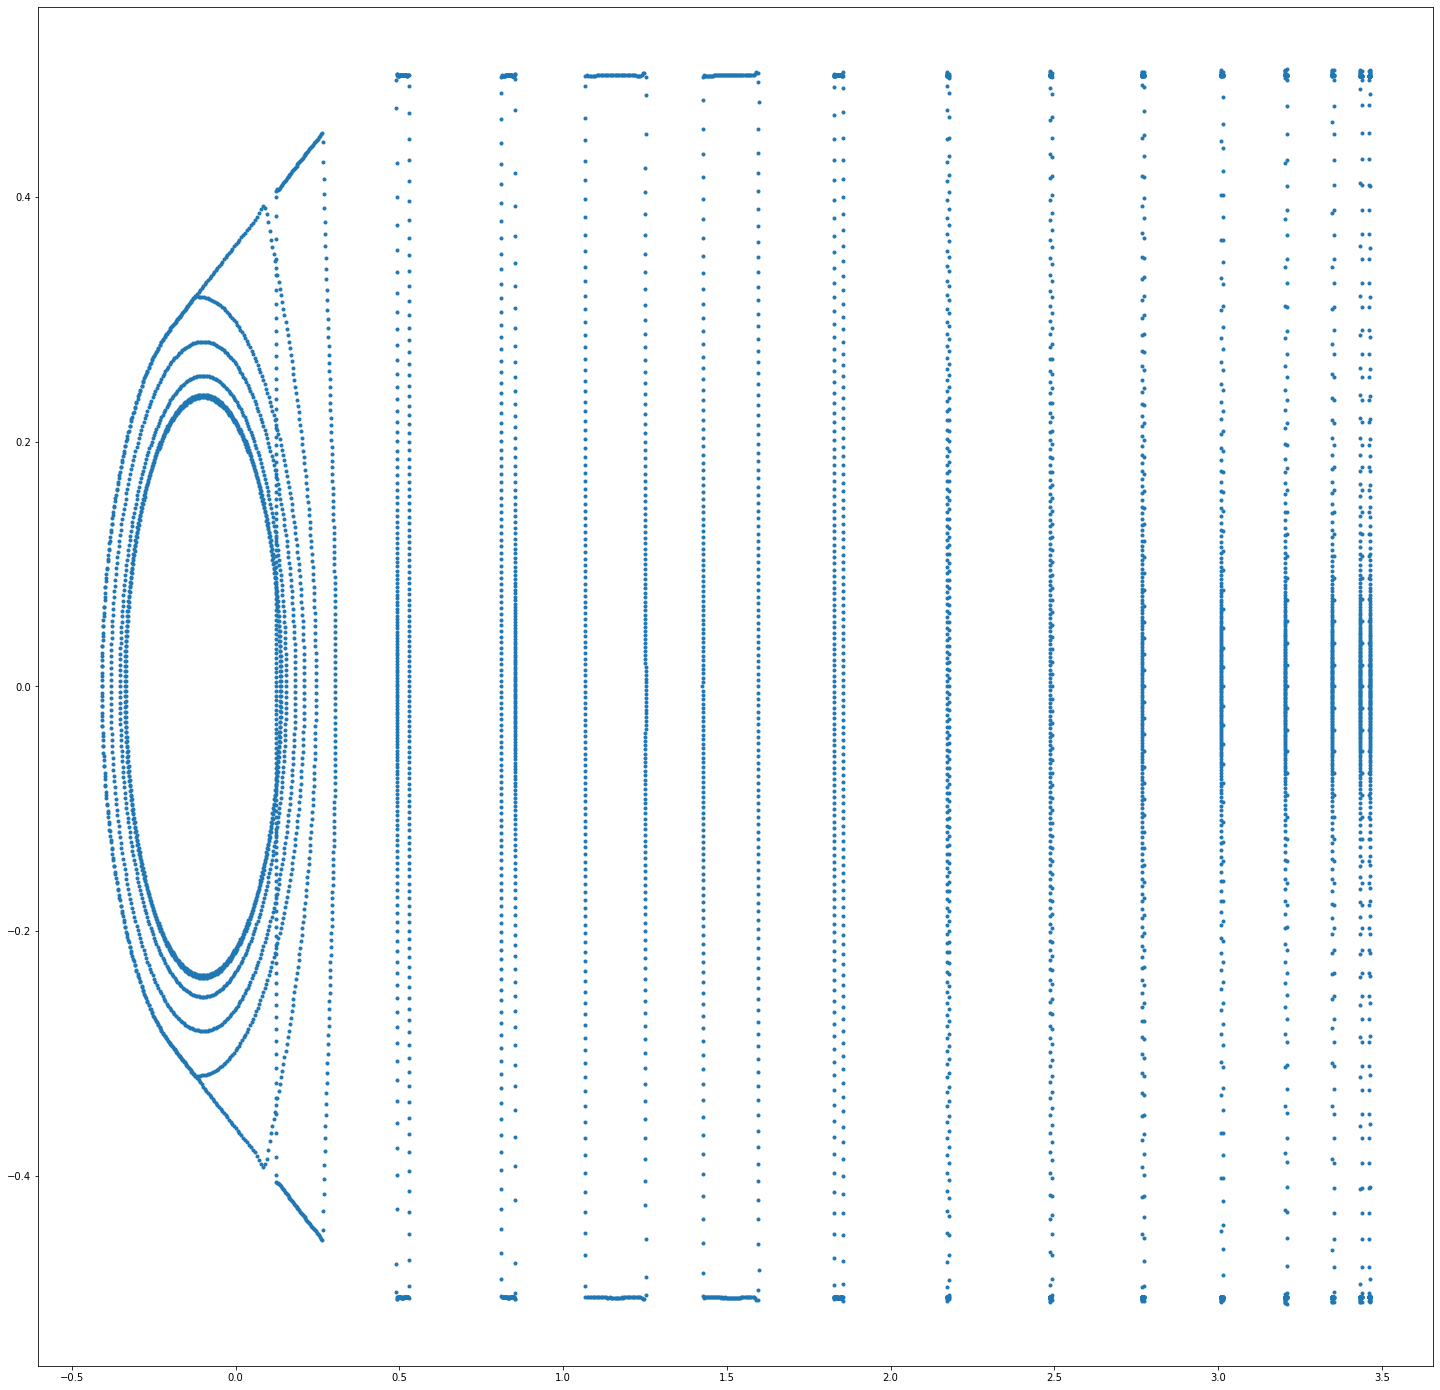

In [7]:
plt.figure(figsize=(25,25))
xc = []
yc = []
zc = []
for k in range(20):
    xc.extend([chebyshev1[k][i][0] for i in range(360)])
    yc.extend([chebyshev1[k][i][1] for i in range(360)])
    zc.extend([chebyshev1[k][i][2] for i in range(360)])
plt.plot(xc, yc, ".")

In [5]:
baseline1chebyshev = open('baseline1chebyshev.txt', 'w')
print(chebyshev1, file = baseline1chebyshev)

In [15]:
def smoothing(r): 

    # r is a 2D matrix that contain the radius r(z,theta) values in the matrix in this format:
    # The columns represent different theta values at any given row
    # The rows represent z along the origin line
    # I.E. Each row is at a specific z on the origin line and the columns on that row represent r values at thetas from 0-2*pi

    # Transforms

    r_f1=scipy.fft.dct(r,axis=0)
    r_f=numpy.fft.rfft(r_f1,axis=1)


    # Smoothing
    cutoff_z=5
    cutoff_theta=120

    r_f_smooth = deepcopy(r_f)

    for k_z in range(r_f.shape[0]):
        for k_theta in range(r_f.shape[1]):
            if k_theta>cutoff_theta and k_z>cutoff_z:
                dist=-1*(k_theta**2+k_z**2)**0.5
                r_f_smooth[k_z,k_theta]=np.exp(dist)*r_f_smooth[k_z,k_theta]



    r_if1=numpy.fft.irfft(r_f_smooth,axis=1)
    r_smooth=scipy.fft.idct(r_if1,axis=0)


    # r is the original matrix. r_smooth is the smoothed out matrix
    
    return r_smooth